In [ ]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!pip install opencv-python
!pip install seaborn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"adityatamhane26","key":"e498a8e8a5b47a825ef764a28aeb2e0c"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:19<00:00, 123MB/s]



In [ ]:
import zipfile

with zipfile.ZipFile("chest-xray-pneumonia.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

In [ ]:
import os

base_dir = "data/chest_xray"

print("Train:", os.listdir(base_dir + "/train"))
print("Test:", os.listdir(base_dir + "/test"))

Train: ['PNEUMONIA', 'NORMAL']
Test: ['PNEUMONIA', 'NORMAL']


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import confusion_matrix

In [ ]:
train_dir = "data/chest_xray/train"
test_dir  = "data/chest_xray/test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


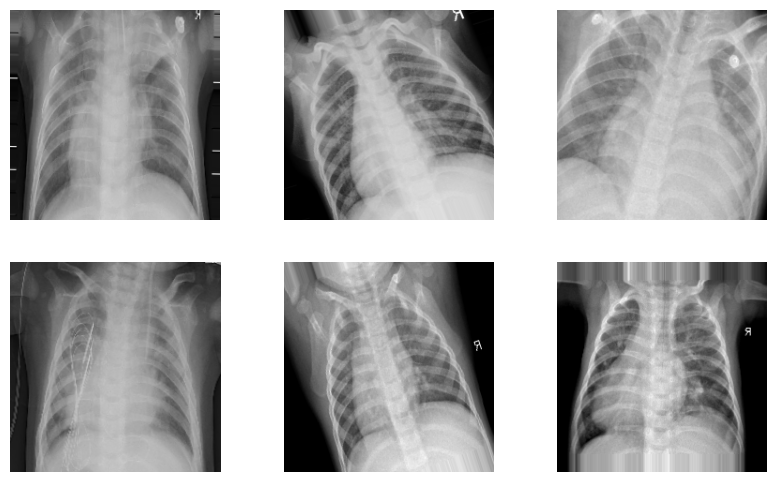

In [ ]:
images, labels = next(train_generator)

plt.figure(figsize=(10,6))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()

In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)

predictions = Dense(
    1,
    activation='sigmoid'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=predictions
)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
EPOCHS = 5

history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=EPOCHS
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 163s 881ms/step - accuracy: 0.8972 - loss: 0.2571 - val_accuracy: 0.8494 - val_loss: 0.3360
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 125s 766ms/step - accuracy: 0.9373 - loss: 0.1628 - val_accuracy: 0.8638 - val_loss: 0.3092
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 125s 762ms/step - accuracy: 0.9469 - loss: 0.1352 - val_accuracy: 0.8654 - val_loss: 0.3273
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 124s 761ms/step - accuracy: 0.9530 - loss: 0.1215 - val_accuracy: 0.8846 - val_loss: 0.2566
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 123s 753ms/step - accuracy: 0.9574 - loss: 0.1157 - val_accuracy: 0.8862 - val_loss: 0.2694


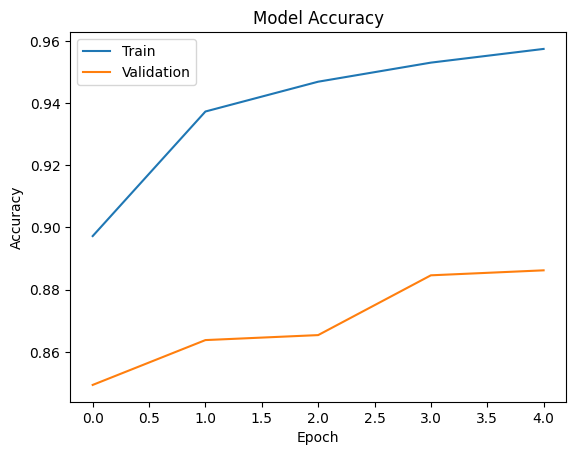

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Train",
    "Validation"
])

plt.savefig("accuracy_plot.png")

plt.show()

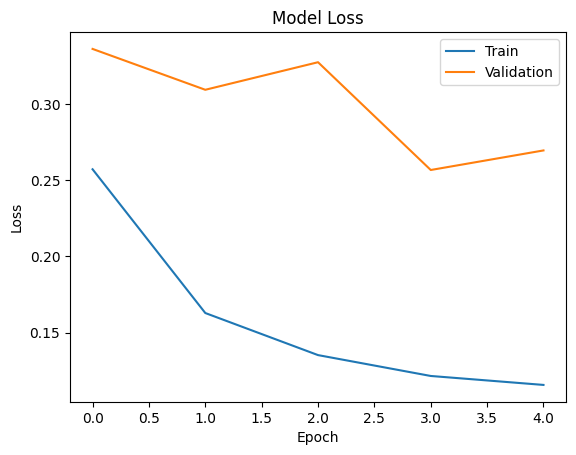

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Train",
    "Validation"
])

plt.savefig("loss_plot.png")

plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 550ms/step


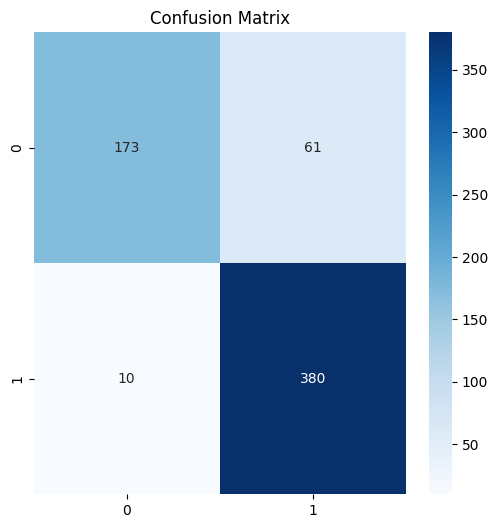

In [ ]:
predictions = model.predict(
    test_generator
)

y_pred = (
    predictions > 0.5
).astype(int)

cm = confusion_matrix(
    test_generator.classes,
    y_pred
)

plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.savefig(
    "confusion_matrix.png"
)

plt.show()

In [ ]:
model.save("pneumonia_model.h5")

In [ ]:
import shutil
import os

source_folder = "data/chest_xray/test/NORMAL"

image_name = os.listdir(source_folder)[0]

shutil.copy(
    os.path.join(source_folder, image_name),
    "test_xray.jpg"
)

print("test_xray.jpg created successfully!")

test_xray.jpg created successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving test_xray.jpg to test_xray (2).jpg


In [ ]:
import cv2
import numpy as np
import tensorflow as tf

model = tf.keras.models.load_model(
    "pneumonia_model.h5"
)

for filename in uploaded.keys():

    img = cv2.imread(filename)

    img = cv2.resize(
        img,
        (224,224)
    )

    img = img / 255.0

    img = np.reshape(
        img,
        (1,224,224,3)
    )

    prediction = model.predict(img)[0][0]

    if prediction > 0.5:
        label = "PNEUMONIA"
    else:
        label = "NORMAL"

    print("Prediction:", label)
    print("Confidence:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
Prediction: NORMAL
Confidence: 0.30842456


In [ ]:
import shutil
import os

source_folder = "data/chest_xray/test/PNEUMONIA"

image_name = os.listdir(source_folder)[0]

shutil.copy(
    os.path.join(source_folder, image_name),
    "test_xray.jpg"
)

print("Pneumonia test image ready!")

Pneumonia test image ready!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving test_xray.jpg to test_xray (1).jpg


In [ ]:
import cv2
import numpy as np
import tensorflow as tf

# Load model
model = tf.keras.models.load_model(
    "pneumonia_model.h5"
)

# Predict uploaded image
for filename in uploaded.keys():

    img = cv2.imread(filename)

    img = cv2.resize(
        img,
        (224,224)
    )

    img = img / 255.0

    img = np.reshape(
        img,
        (1,224,224,3)
    )

    prediction = model.predict(img)[0][0]

    if prediction > 0.5:
        label = "PNEUMONIA"
    else:
        label = "NORMAL"

    print("Prediction:", label)
    print("Confidence:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Prediction: PNEUMONIA
Confidence: 0.9689568


In [ ]:
import shutil

save_path = "/content/drive/MyDrive/Medical_AI_Output/"

os.makedirs(save_path, exist_ok=True)

files_to_save = [
    "accuracy_plot.png",
    "loss_plot.png",
    "confusion_matrix.png",
    "pneumonia_model.h5"
]

for f in files_to_save:

    shutil.copy(
        f,
        save_path + f
    )

print("Files saved to Google Drive!")

Files saved to Google Drive!
